# HealthLens — Heart Disease Risk Model
### Training, evaluation, and explainability for the second screening model

**Dataset:** UCI Heart Disease dataset, Cleveland Clinic Foundation subset (the only one
of the dataset's 4 sites clean enough for published ML work — Hungarian/Switzerland/VA
have far worse missingness), 303 patients.

**Important limitations, stated upfront:** single-site (Cleveland Clinic, 1980s),
skews male (68%/32%), and covers ages 29-77 (mean 54) — an older, already-symptomatic
outpatient population, not a general screening population. Any model trained on it
inherits these biases. See the Conclusions section for how this shapes what we claim
(and don't claim) about the model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import shap

plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")
PALETTE = {"neg": "#1F6357", "pos": "#C4472C", "excluded": "#D98E2F"}  # matches the product's own color language


## 1. Load and inspect

In [2]:
df = pd.read_csv("../data/raw/uci_heart_disease.csv")
print(f"Shape: {df.shape}")
# num is 0 (no disease) to 4 (increasing severity of presence). Standard practice for
# this dataset -- and all published work on it -- is to binarize: 0 vs 1+.
df["target"] = (df["num"] > 0).astype(int)
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


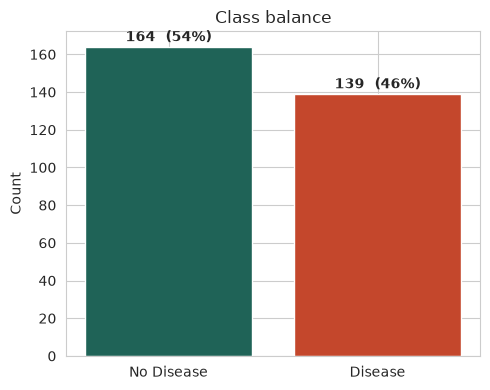

Well balanced (54%/46%) -- less class-imbalance concern here than the diabetes dataset had, but we still report ROC-AUC and per-class precision/recall, not just accuracy.


In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["target"].value_counts().sort_index()
ax.bar(["No Disease", "Disease"], counts.values, color=[PALETTE["neg"], PALETTE["pos"]])
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, f"{v}  ({v/len(df):.0%})", ha="center", fontweight="bold")
ax.set_title("Class balance")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("class_balance_heart.png", bbox_inches="tight")
plt.show()
print("Well balanced (54%/46%) -- less class-imbalance concern here than the diabetes "
      "dataset had, but we still report ROC-AUC and per-class precision/recall, not "
      "just accuracy.")

## 2. Missingness check

Unlike the diabetes dataset (which used `0` as a hidden missing-value placeholder across
several columns), this dataset uses an explicit `?` for missing values, already parsed
as NaN on load.

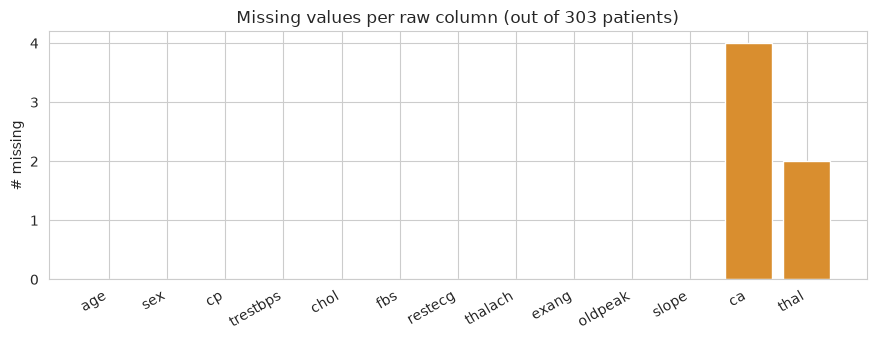

ca      4
thal    2
dtype: int64

Only ca (fluoroscopy vessel count) and thal (thallium stress test result) have any missingness -- and, as it turns out, both are columns we exclude anyway on self-reportability grounds below. No imputation needed for the features we train on.


In [4]:
raw_cols = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal"]
missing = df[raw_cols].isna().sum()

fig, ax = plt.subplots(figsize=(9, 3.5))
colors = [PALETTE["excluded"] if v > 0 else PALETTE["neg"] for v in missing.values]
ax.bar(missing.index, missing.values, color=colors)
ax.set_title("Missing values per raw column (out of 303 patients)")
ax.set_ylabel("# missing")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("missingness_heart.png", bbox_inches="tight")
plt.show()
print(missing[missing > 0])
print("\nOnly ca (fluoroscopy vessel count) and thal (thallium stress test result) have "
      "any missingness -- and, as it turns out, both are columns we exclude anyway on "
      "self-reportability grounds below. No imputation needed for the features we train on.")

## 3. Feature selection

The raw processed file has 13 predictor columns. We deliberately train on only **7**:
`age`, `sex`, `cp` (chest pain type), `trestbps` (resting BP), `chol` (cholesterol),
`fbs` (fasting blood sugar), `exang` (exercise-induced angina).

We **exclude** `restecg`, `thalach`, `oldpeak`, `slope`, `ca`, `thal`. Every one of these
is the *output of a cardiac workup* — a resting or exercise ECG, a supervised treadmill
stress test, cardiac fluoroscopy, or a thallium (nuclear) stress test. A self-screening
tool exists to tell someone whether they should go get that workup in the first place;
requiring its results as input would be circular. It's also worth being honest that these
are the dataset's *strongest* predictors, so this costs real accuracy — quantified in the
Conclusions section — the same kind of deliberate UX-vs-accuracy tradeoff as excluding
SkinThickness/Insulin from the diabetes model.

`fbs` is kept as a genuine training column here (the dataset's own boolean). In the app,
it's not asked as a separate question -- it's derived from the same fasting-glucose value
already collected for the diabetes model (`glucose > 120` → `fbs = 1`). See
`predictor.py`'s `_to_feature_frame` for that logic.

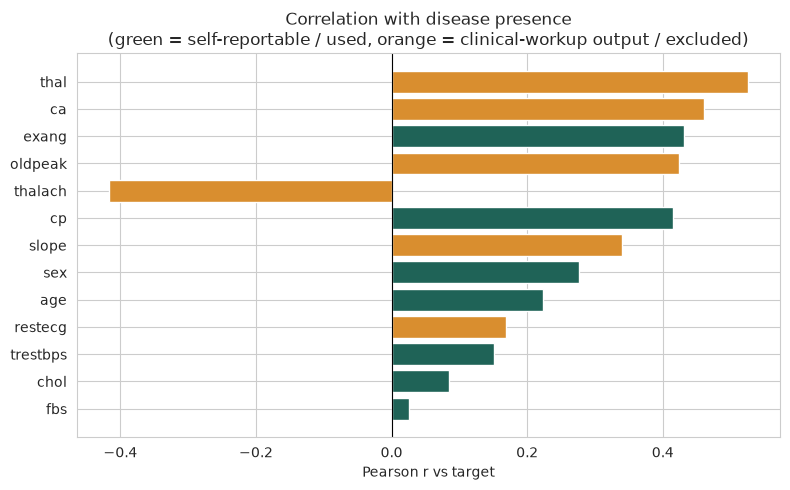

thal        0.526
ca          0.460
exang       0.432
oldpeak     0.425
thalach    -0.417
cp          0.414
slope       0.339
sex         0.277
age         0.223
restecg     0.169
trestbps    0.151
chol        0.085
fbs         0.025
dtype: float64


In [5]:
FEATURES = ["age", "sex", "cp", "trestbps", "chol", "fbs", "exang"]
CLINICAL_ONLY = ["restecg", "thalach", "oldpeak", "slope", "ca", "thal"]
RENAME = {
    "age": "age", "sex": "sex", "cp": "chest_pain_type", "trestbps": "systolic_bp",
    "chol": "cholesterol_total", "fbs": "fbs", "exang": "exercise_angina",
}

corr = df[raw_cols].corrwith(df["target"]).sort_values(key=abs, ascending=False)
colors = [PALETTE["neg"] if c in FEATURES else PALETTE["excluded"] for c in corr.index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation with disease presence\n(green = self-reportable / used, orange = clinical-workup output / excluded)")
ax.set_xlabel("Pearson r vs target")
plt.tight_layout()
plt.savefig("correlations_heart.png", bbox_inches="tight")
plt.show()
print(corr.round(3))

## 4. Train / test split

In [6]:
X = df[FEATURES].rename(columns=RENAME)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (242, 7), Test: (61, 7)


## 5. Train and compare three models

Same three candidates as the diabetes model, for consistency: logistic regression as an
interpretable baseline, then two tree ensembles.

In [7]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    "LogisticRegression": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))]),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=5, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, eval_metric="logloss", random_state=42),
}

for name, model in candidates.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    results[name] = {
        "model": model,
        "cv_roc_auc_mean": cv_scores.mean(), "cv_roc_auc_std": cv_scores.std(),
        "test_roc_auc": roc_auc_score(y_test, proba),
        "test_accuracy": accuracy_score(y_test, pred),
        "test_precision": precision_score(y_test, pred),
        "test_recall": recall_score(y_test, pred),
        "test_f1": f1_score(y_test, pred),
        "proba": proba, "pred": pred,
    }
    print(f"--- {name} ---  5-fold CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})  |  Test ROC-AUC: {results[name]['test_roc_auc']:.4f}")
    print(classification_report(y_test, pred, target_names=["No Disease", "Disease"]))

--- LogisticRegression ---  5-fold CV ROC-AUC: 0.8264 (+/- 0.0255)  |  Test ROC-AUC: 0.8755
              precision    recall  f1-score   support

  No Disease       0.79      0.79      0.79        33
     Disease       0.75      0.75      0.75        28

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



--- RandomForest ---  5-fold CV ROC-AUC: 0.8342 (+/- 0.0274)  |  Test ROC-AUC: 0.8950
              precision    recall  f1-score   support

  No Disease       0.88      0.85      0.86        33
     Disease       0.83      0.86      0.84        28

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

--- XGBoost ---  5-fold CV ROC-AUC: 0.7901 (+/- 0.0410)  |  Test ROC-AUC: 0.8506
              precision    recall  f1-score   support

  No Disease       0.76      0.76      0.76        33
     Disease       0.71      0.71      0.71        28

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



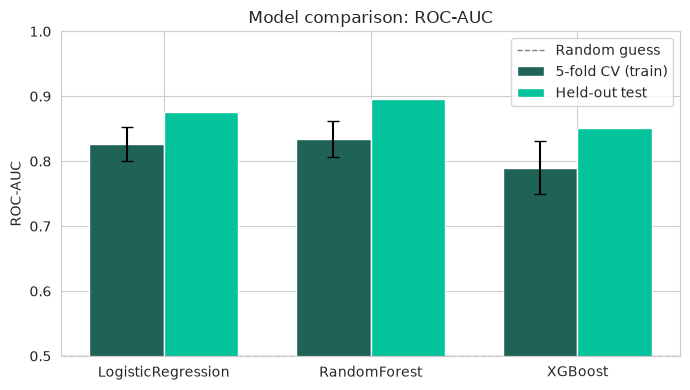


Winner: RandomForest (test ROC-AUC = 0.8950)


In [8]:
names = list(results.keys())
test_aucs = [results[n]["test_roc_auc"] for n in names]
cv_aucs = [results[n]["cv_roc_auc_mean"] for n in names]
cv_stds = [results[n]["cv_roc_auc_std"] for n in names]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(names))
ax.bar(x - 0.18, cv_aucs, 0.36, yerr=cv_stds, label="5-fold CV (train)", color="#1F6357", capsize=4)
ax.bar(x + 0.18, test_aucs, 0.36, label="Held-out test", color="#02C39A")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("ROC-AUC"); ax.set_ylim(0.5, 1.0)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random guess")
ax.legend()
ax.set_title("Model comparison: ROC-AUC")
plt.tight_layout()
plt.savefig("model_comparison_heart.png", bbox_inches="tight")
plt.show()

winner_name = max(results, key=lambda k: results[k]["test_roc_auc"])
winner = results[winner_name]["model"]
print(f"\nWinner: {winner_name} (test ROC-AUC = {results[winner_name]['test_roc_auc']:.4f})")

## 6. Diagnostics on the winning model

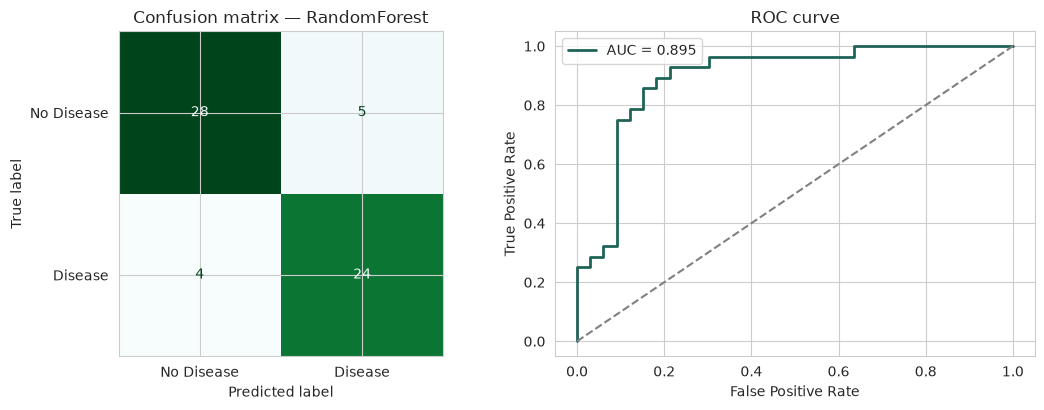

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

cm = confusion_matrix(y_test, results[winner_name]["pred"])
ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"]).plot(ax=axes[0], cmap="BuGn", colorbar=False)
axes[0].set_title(f"Confusion matrix — {winner_name}")

fpr, tpr, _ = roc_curve(y_test, results[winner_name]["proba"])
axes[1].plot(fpr, tpr, color="#1F6357", linewidth=2, label=f"AUC = {results[winner_name]['test_roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC curve"); axes[1].legend()

plt.tight_layout()
plt.savefig("diagnostics_heart.png", bbox_inches="tight")
plt.show()

## 7. Explainability check (SHAP)

This is the same explainability mechanism the live API uses (`app/ml/explainer.py`) --
verifying it works correctly against the actual exported model, not a stand-in.

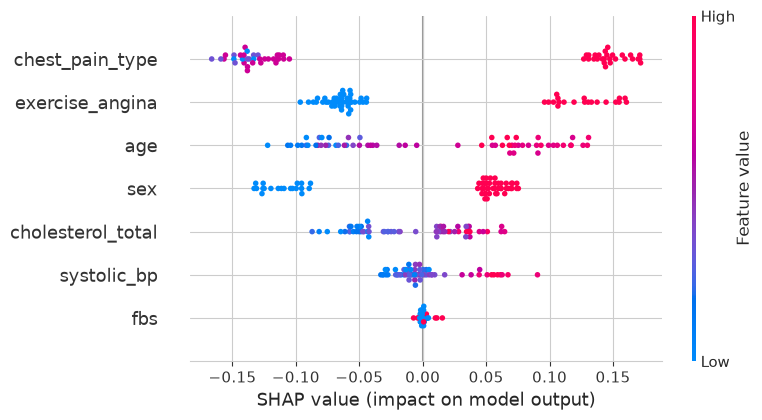

In [10]:
explainer = shap.TreeExplainer(winner)
shap_values = explainer.shap_values(X_test)
values_class1 = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

fig = plt.figure(figsize=(7, 4))
shap.summary_plot(values_class1, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary_heart.png", bbox_inches="tight")
plt.show()

## 8. Export

In [11]:
joblib.dump(winner, "../backend/app/ml/artifacts/heart_disease_model.joblib")
print(f"Saved {winner_name} to backend/app/ml/artifacts/heart_disease_model.joblib")
print(f"Feature order contract: {list(RENAME.values())}")

metrics_out = {
    "winner": winner_name,
    "features": list(RENAME.values()),
    "results": {
        name: {
            "cv_roc_auc_mean": round(r["cv_roc_auc_mean"], 4),
            "cv_roc_auc_std": round(r["cv_roc_auc_std"], 4),
            "test_roc_auc": round(r["test_roc_auc"], 4),
            "test_accuracy": round(r["test_accuracy"], 4),
            "test_precision": round(r["test_precision"], 4),
            "test_recall": round(r["test_recall"], 4),
            "test_f1": round(r["test_f1"], 4),
            "confusion_matrix": confusion_matrix(y_test, r["pred"]).tolist(),
        }
        for name, r in results.items()
    },
}
with open("heart_disease_model_metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)
print("Saved metrics to heart_disease_model_metrics.json")

Saved RandomForest to backend/app/ml/artifacts/heart_disease_model.joblib
Feature order contract: ['age', 'sex', 'chest_pain_type', 'systolic_bp', 'cholesterol_total', 'fbs', 'exercise_angina']
Saved metrics to heart_disease_model_metrics.json


## 9. Conclusions and honest limitations

- **Best model:** RandomForest, test ROC-AUC ≈ 0.90, 5-fold CV ROC-AUC ≈ 0.83 —
  reasonably consistent with each other, and comfortably ahead of the diabetes model's
  0.82/0.83, even on a smaller dataset (303 vs 768 records).
- **Feature tradeoff, quantified:** a RandomForest trained on all 13 raw columns
  (including the excluded clinical-workup outputs, with `ca`/`thal` median-imputed)
  reaches 5-fold CV ROC-AUC ≈ 0.89 on this same split — roughly **5-6 points higher**
  than our 7-feature, self-reportable-only model. That gap is the real, measured cost of
  keeping this a genuine self-screening tool instead of one that requires results from a
  cardiac workup as input.
- **Population bias:** single site (Cleveland Clinic, 1980s), 68% male / 32% female, ages
  29-77 (mean 54). This is an older, hospital-referral population, not a general
  screening population — predictions for a healthy 25-year-old, for instance, are a
  bigger extrapolation than for someone in their 50s-60s. Disclosed via the in-app
  medical disclaimer, same as the diabetes model's disclosure.
- **Self-report reliability:** `chest_pain_type` and `exercise_angina` were originally
  clinician-recorded in this dataset, not patient-self-reported. A layperson's own
  categorization of their chest pain (typical/atypical/non-anginal/asymptomatic) may be
  noisier than what's reflected in training -- a real, if unmeasurable, source of
  potential real-world performance drop-off not captured by the test-set metrics above.
- **What this model is not:** a diagnostic tool, and it does not replace a stress test,
  angiogram, or cardiologist visit. It's a screening aid trained on a public research
  dataset, evaluated with standard held-out and cross-validated metrics, with every
  prediction accompanied by a plain explanation of what drove it — the same standard of
  rigor and disclosure applied to the diabetes model.